# Sequence-space Jacobians and fake news

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sim_steady_state_fast as sim
import sim_fake_news
from sim_transition import transition

from calibration import make_calibration

In [2]:
# for plotting: uncomment second line to get plots with exact style
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'figure.figsize': (6, 3)})
plt.rcParams.update({'text.usetex': True, 'font.serif': 'Palatino'})

## Structure of this notebook
This notebook develops the figures in the lecture 3 slides for sequence-space Jacobians and fake-news matrices.

At the end, it explicitly implements the fake news algorithm to calculate $\mathbf{M}$. This code is generalized in `sim_fake_news.py` to allow it to be calculated with respect to more shocks.

## Calibration
To start, load the "low asset" lecture 1 calibration, which targets assets equal to 100\% of GDP.

In [3]:
calib, e = make_calibration(lowA=True)
r = calib['r']
ss = sim.steady_state(**calib)
assert np.isclose(ss['A'] / 4, 1) # targeted A=100% of annual GDP

## Intertemporal MPCs and asset Jacobian
Now calculate the consumption Jacobian ("intertemporal MPCs") and the asset Jacobian in response to changes in the after-tax wage $Z$, and plot:

In [4]:
T = 500
Js = sim_fake_news.jacobian(ss, {'Z': {'y': e}}, T=T) # y = Z*e, so dZ changes y in proportion to e
M, A = Js['C']['Z'], Js['A']['Z']
assert np.isclose(M[0, 0], 0.2) # targeted impact weighted MPC = 0.2

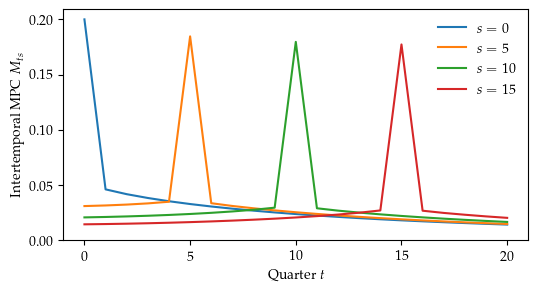

In [5]:
for s in (0, 5, 10, 15):
    plt.plot(M[:21, s], label=fr'$s={s}$')
plt.xlabel(r'Quarter $t$')
plt.xticks([0, 5, 10, 15, 20])
plt.yticks([0, .05, .10, .15, .20])
plt.ylabel(r'Intertemporal MPC $M_{ts}$')
plt.legend(frameon=False)
plt.savefig("figures/lecture3_fig1.pdf", transparent=True, bbox_inches='tight')

## Fake news matrix visualization

In [6]:
F = M.copy()
F[1:, 1:] -= M[:-1, :-1]        # F_(t,s) = M_(t,s) - M_(t-1,s-1)

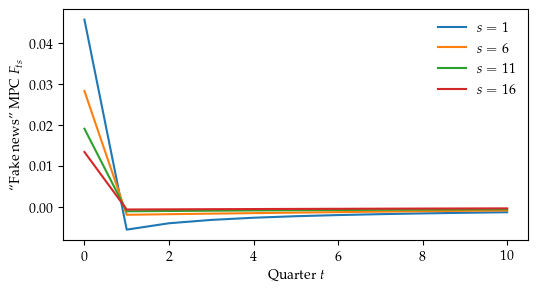

In [7]:
for s in (1, 6, 11, 16):
    plt.plot(F[:11, s], label=fr'$s={s}$')
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'``Fake news" MPC $F_{ts}$')
plt.legend(frameon=False)
plt.savefig("figures/lecture3_fig2.pdf", transparent=True, bbox_inches='tight')

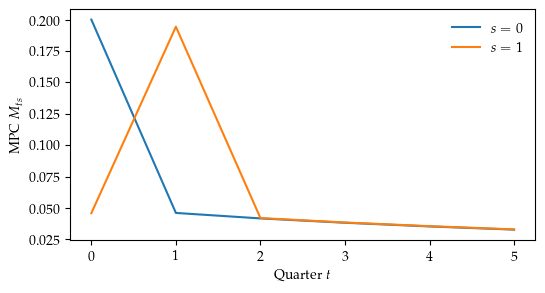

In [8]:
for s in (0, 1):
    plt.plot(M[:6, s], label=fr'$s={s}$')
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'MPC $M_{ts}$')
plt.legend(frameon=False)
plt.savefig("figures/lecture3_fig3.pdf", transparent=True, bbox_inches='tight')

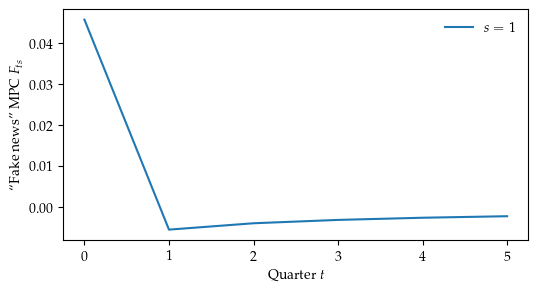

In [9]:
for s in (1,):
    plt.plot(F[:6, s], label=fr'$s={s}$')
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'``Fake news" MPC $F_{ts}$')
plt.legend(frameon=False)
plt.savefig("figures/lecture3_fig4.pdf", transparent=True, bbox_inches='tight')

## General equilibrium solution: linear and nonlinear

Use the same tax cut shock as in lecture 2, now scaled so that the initial tax cut is large (5% of GDP).

In [10]:
rho_B, rho = 0.975, 0.9

dT_shock = -rho**np.arange(T)
dB = np.empty_like(dT_shock)
dB[0] = -dT_shock[0]
for t in range(1, T):
    dB[t] = rho_B * dB[t-1] - dT_shock[t]

dT = np.empty_like(dT_shock)
dT[0] = -dB[0]
dT[1:] = -dB[1:] + (1 + r) * dB[:-1]

dT *= 0.05
dB *= 0.05
assert dT[0] == -0.05

For the linearized economy, simply solve the asset-space IKC to get the impulse response to this shock:

In [11]:
dY_linear = np.linalg.solve(A, dB) + dT

For the nonlinear economy, we iterate on guesses using a variant of Newton's method:

In [12]:
dY_nonlin = dY_linear.copy()
for it in range(20):
    # np.outer(dY_nonlin - dT, e) is T * n_e array giving the path of net income changes
    A_path, _ = transition(ss, T, dy=np.outer(dY_nonlin - dT, e))
    asset_residual = A_path - ss['A'] - dB
    if np.max(np.abs(asset_residual)) < 1e-10:
        print(f'Converged in {it} iterations')
        break
    dY_nonlin -= np.linalg.solve(A, asset_residual)

Converged in 7 iterations


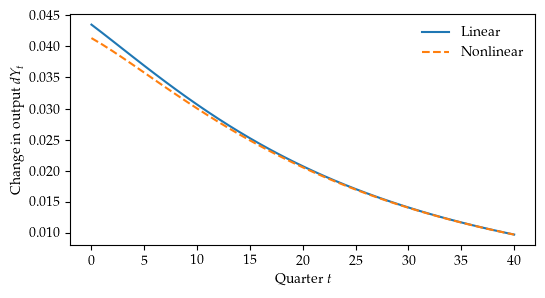

In [ ]:
plt.plot(dY_linear[:41], label='Linear')
plt.plot(dY_nonlin[:41], '--', label='Nonlinear')
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'Change in output $Y_t$ (as % of steady state)')
plt.legend(frameon=False)
plt.savefig("figures/lecture3_fig5.pdf", transparent=True, bbox_inches='tight')

## Fake news algorithm for intertemporal MPCs
This is generalized by `sim_fake_news.py` to allow for arbitrary shocks (rather than just to $Z$ here) and also to obtain the Jacobians for both assets and consumption in response to those shocks (rather than just $C$ here).

**Step 1: backward iteration.** First, iterate backward in response to a small shock to income, and store the $\mathcal{Y}_s$ (how does the consumption policy change in response to income in $s$ periods affect aggregate consumption today?) and $\mathcal{D}_s$ (how does the asset policy change in response to income in $s$ periods affect the distribution going into tomorrow?).

In [14]:
# preliminaries: get steady-state inputs, allocate arrays for curlyY and curlyD
ss_inputs = {k: ss[k] for k in ('Va', 'Pi', 'a_grid', 'y', 'r', 'beta', 'eis')}
curlyY = np.empty(T)
curlyD = np.empty((T,) + ss['D'].shape)

# slight numerical robustness: what does forward iteration give without shock?
D1_noshock = sim.forward_iteration(ss['D'], ss['Pi'], ss['a_i'], ss['a_pi'])

h = 1E-4
for s in range(T):
    if s == 0:
        # Z shock today, so tomorrow's Va is steady state, and we change income
        Va, a, c = sim.backward_iteration(**{**ss_inputs, 'y': ss['y'] + h*e})
    else:
        # Z shock in future, so income is steady state, take in last Va
        Va, a, c = sim.backward_iteration(**{**ss_inputs, 'Va': Va})
    
    # aggregate effect on C
    curlyY[s] = np.vdot(ss['D'], c - ss['c']) / h

    # what is effect on one-period-ahead distribution?
    a_i_shocked, a_pi_shocked = sim.interpolate_lottery_loop(a, ss['a_grid'])
    curlyD[s] = (sim.forward_iteration(ss['D'], ss['Pi'], a_i_shocked, a_pi_shocked) - D1_noshock) / h

**Step 2: expectation iteration.**
Expectation iterations are already defined in `sim_steady_state.py` and `sim_steady_state_fast.py`, and explained in the supplementary notebook `sim_steady_state_computation.ipynb` (and video lectures).

These correspond to repeatedly taking one-period-ahead expectations using the steady-state transition matrix across states $(e,a)$, starting with whatever our outcome of interest is—in this case, consumption. (Though the matrix is never explicitly constructed; it's better to leave implicit.)

In [15]:
curlyE = sim.expectation_functions(ss['c'], ss['Pi'], ss['a_i'], ss['a_pi'], T-1)

**Step 3: form fake news matrix.**

In [16]:
F = np.empty((T, T))
    
# t=0: F[0, s] = curlyY[o][s] for all s
F[0, :] = curlyY

# t>0: F[t, s] = dot product of curlyE[t-1] with curlyD[s]
# can write this as following (easier to read):
# for t in range(1, T):
#     for s in range(T):
#         F[o][t, s] = np.vdot(curlyE[o][t-1], curlyD[s])

# but for efficiency, we write as an equivalent single matrix multiplication instead
F[1:, :] = curlyE.reshape(T-1, -1) @ curlyD.reshape(T, -1).T

**Step 4: build up from fake news matrix to Jacobian.** Here, we implement the recursion $M_{t,s} = F_{t,s} + M_{t-1,s-1}$.

In [17]:
Mnew = F.copy()
for s in range(1, T):
    Mnew[1:, s] += Mnew[:-1, s-1]  # M_(t,s) = F_(t,s) + M_(t-1,s-1)

Let's validate that this is the same as the `M` we already obtained with the more general `sim_fake_news.jacobian()` routine. In this case, it's literally identical:

In [18]:
np.max(np.abs(Mnew - M))

np.float64(0.0)